# **TUGAS 5 - Decision Tree Regression**

**Kelompok 11 - Statistika 2023A**


Anggota Kelompok :
- Nisrina Alissy (1314623008)
- Jessica Aurelia P. (1314623031)

**Deskripsi Projek**

Proyek ini bertujuan untuk memprediksi biaya asuransi (charges) menggunakan metode Decision Tree Regression. Data yang digunakan merupakan data asuransi dengan beberapa variabel prediktor, yaitu age, sex, bmi, children, smoker, dan region, dengan variabel target berupa charges.

Pada penelitian ini, digunakan tiga pendekatan pemodelan:



1.   Decision Tree Regression tanpa tuning hyperparameter (menggunakan parameter default)
2.   Decision Tree Regression dengan tuning hyperparameter untuk mengoptimalkan performa model
3.   Random Forest Regression sebagai model pembanding berbasis ensemble learning.



Input data

In [ ]:
#Import library yang digunakan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#input data
link = "https://raw.githubusercontent.com/alissysays/SMT5_NA/refs/heads/main/RAW%20DATA/insurance.csv"
df = pd.read_csv(link)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# EDA

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# Mengecek missing value
df.isna().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
# checking unique values
df.nunique()

,0
age,47
sex,2
bmi,548
children,6
smoker,2
region,4
charges,1337


In [ ]:
#Cek apakah terdapat duplikat data
df.duplicated().any()

np.True_

In [ ]:
#Memeriksa jumlah baris yang terduplikat
jumlah_duplikat = df.duplicated().sum()
print(f"Total baris duplikat yang ditemukan: {jumlah_duplikat}")

Total baris duplikat yang ditemukan: 1


In [ ]:
#ringkasan statistik
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


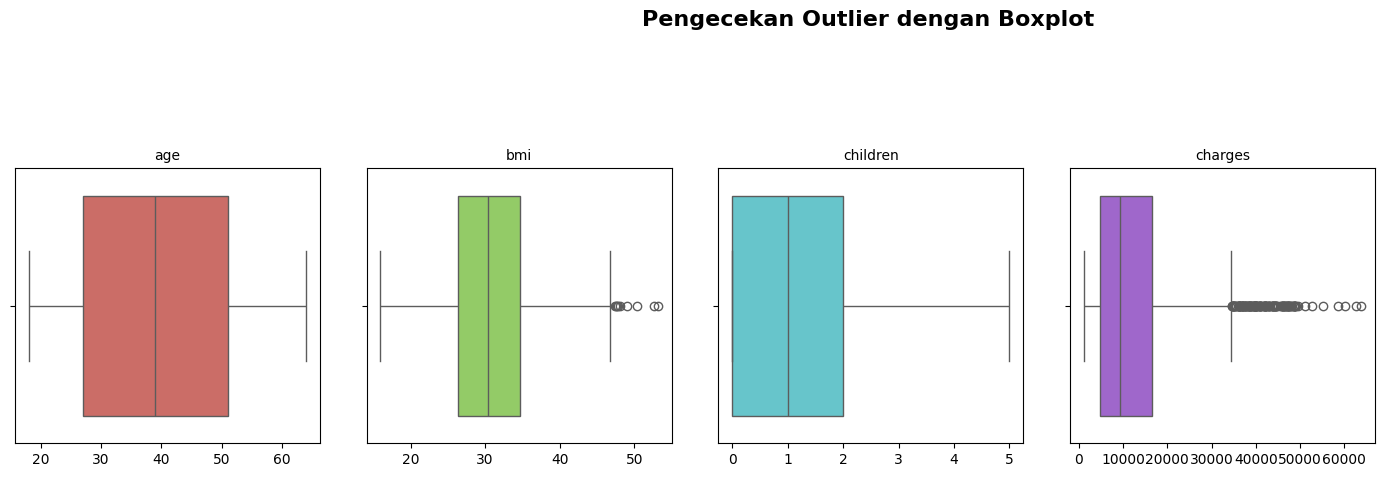

In [ ]:
#cek outlier
# Boxplot untuk mengecek outlier (dengan data awal)
kolom_numerik = df.describe().columns[:4]
# Buat palet
palette = sns.color_palette("hls", len(kolom_numerik))
plt.figure(figsize=(18, 18))

# Loop melalui kolom dan indeks
for i in enumerate(kolom_numerik):
    # i[0] adalah indeks (0, 1, 2...), i[1] adalah nama kolom
    plt.subplot(5, 5, i[0] + 1)
    sns.boxplot(
        x=df[i[1]],
        color=palette[i[0]]
    )
    plt.title(i[1], fontsize=10)
    plt.xlabel('')

plt.suptitle("Pengecekan Outlier dengan Boxplot", y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout(pad=3.0) # Menambahkan padding agar lebih rapi
plt.show()

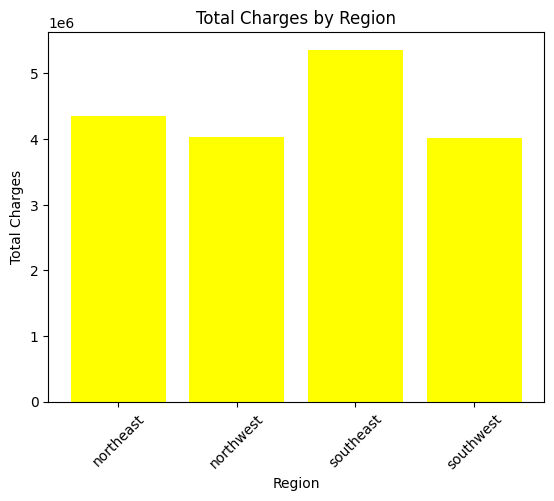

In [ ]:
# Total Charge berdasarkan region (daerah)
charges_by_region = df.groupby('region')['charges'].sum()

# Create a bar chart
plt.bar(charges_by_region.index, charges_by_region.values, color='yellow')

# Add labels and title
plt.xlabel('Region')

plt.ylabel('Total Charges')
plt.title('Total Charges by Region')

# Rotate x-axis labels for better visibility (optional)
plt.xticks(rotation=45)

# Display the chart
plt.show()

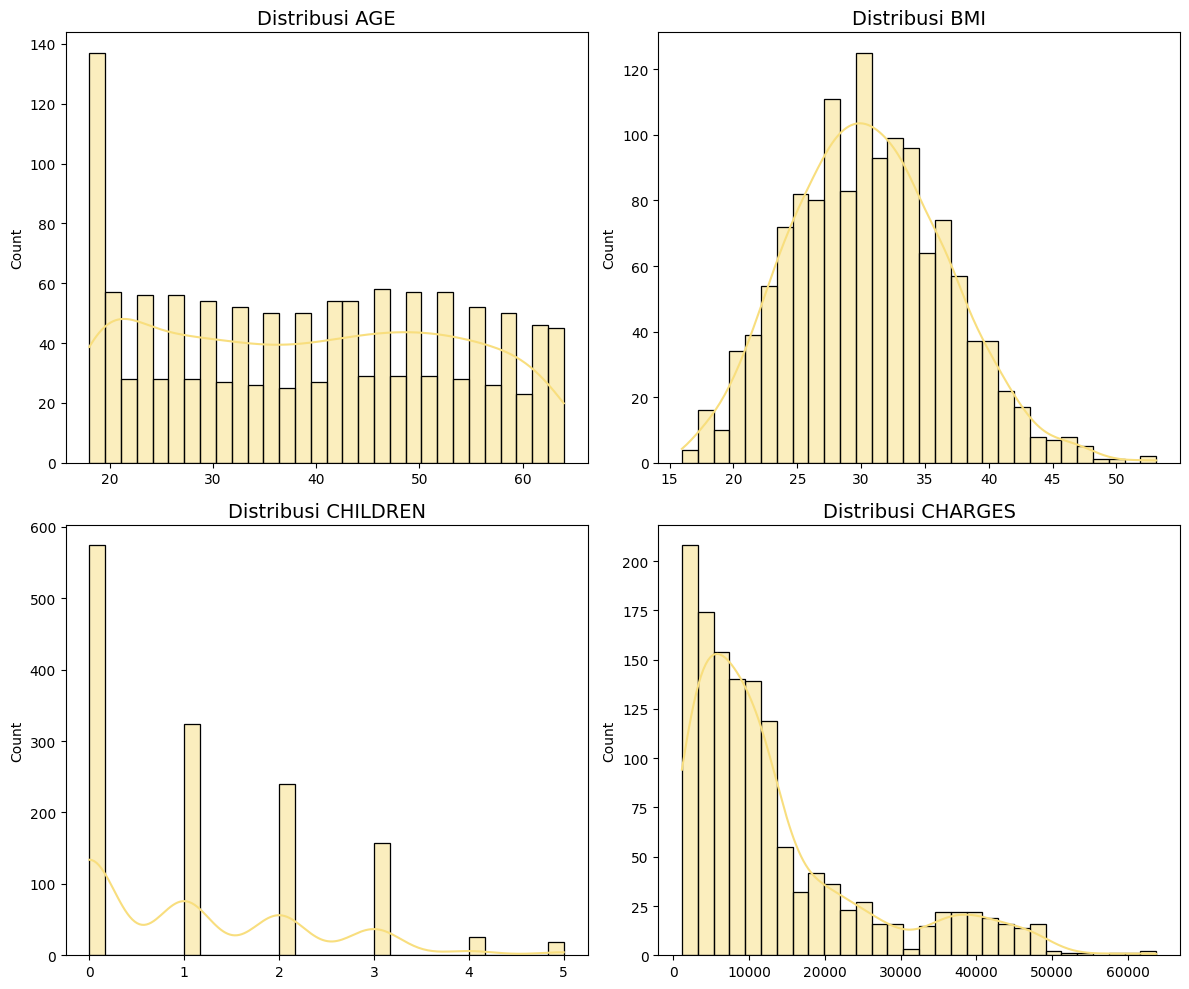

In [ ]:
# Histogram variabel numerik
numerical_cols = ['age', 'bmi', 'children', 'charges']

# Membuathistogram
n_rows = 2
n_cols = 2

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 10))

for i, feature in enumerate(numerical_cols):
    row = i // n_cols
    col = i % n_cols

    sns.histplot(
        data=df,
        x=feature,
        ax=axes[row, col],
        bins=30,
        kde=True, # Biar lebih informatif
        color='#F8DE7E'
    )

    axes[row, col].grid(False)
    axes[row, col].set_title(f'Distribusi {feature.upper()}', fontsize=14)
    axes[row, col].set_xlabel('')

plt.tight_layout()
plt.show()

/tmp/ipython-input-1575114448.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipython-input-1575114448.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipython-input-1575114448.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


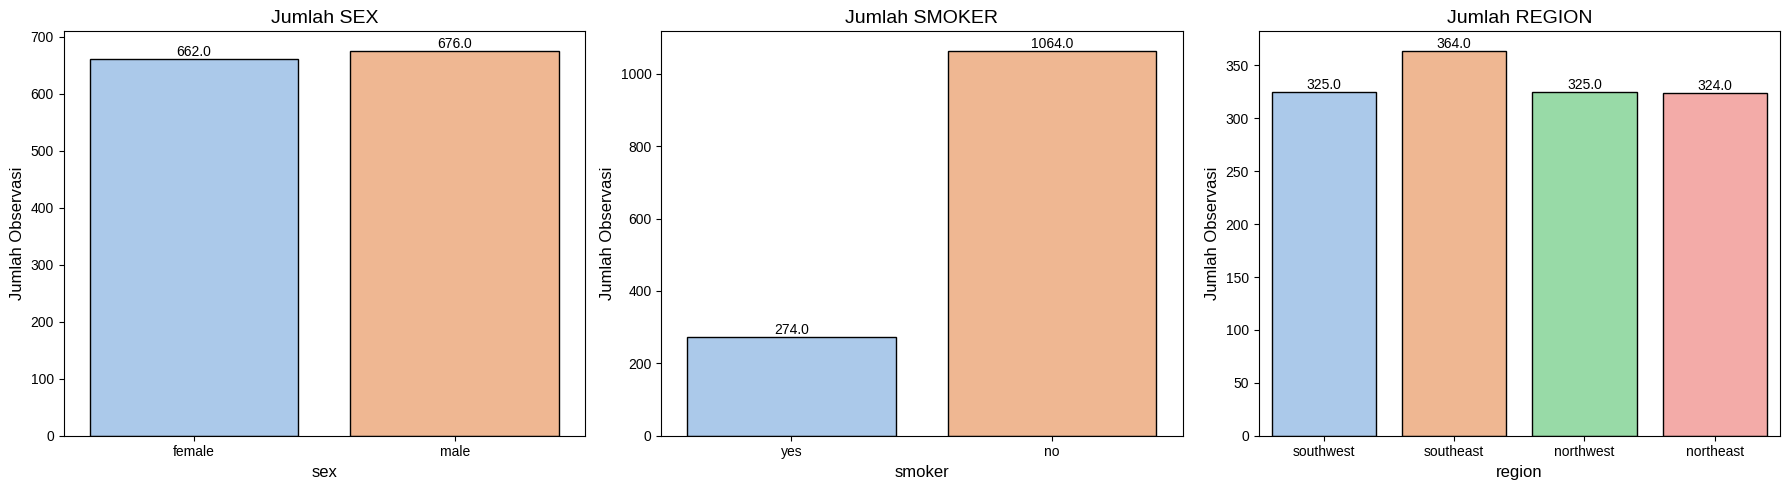

In [ ]:
# Fitur kategorikal yang akan diplot
categorical_features = ['sex', 'smoker', 'region']

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
plt.style.use('seaborn-v0_8-whitegrid')

# iterasi untuk setiap fitur
for i, feature in enumerate(categorical_features):

    # Membuat Count Plot (Bar Plot Frekuensi)
    sns.countplot(
        x=feature,              # Variabel kategorikal di sumbu X
        data=df,                # DataFrame
        ax=axes[i],             # Plot di subplot ke-i
        palette='pastel',      # Pilihan skema warna
        edgecolor='black'       # Garis tepi bar
    )

    # Menambahkan judul dan label
    axes[i].set_title(f'Jumlah {feature.upper()}', fontsize=14)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('Jumlah Observasi', fontsize=12)

    #Menampilkan nilai hitungan di atas bar
    for p in axes[i].patches:
        axes[i].annotate(
            f'{p.get_height()}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
            textcoords='offset points'
        )

# 3. Tampilkan Plot
plt.tight_layout() # Sesuaikan jarak antar subplot
plt.show()

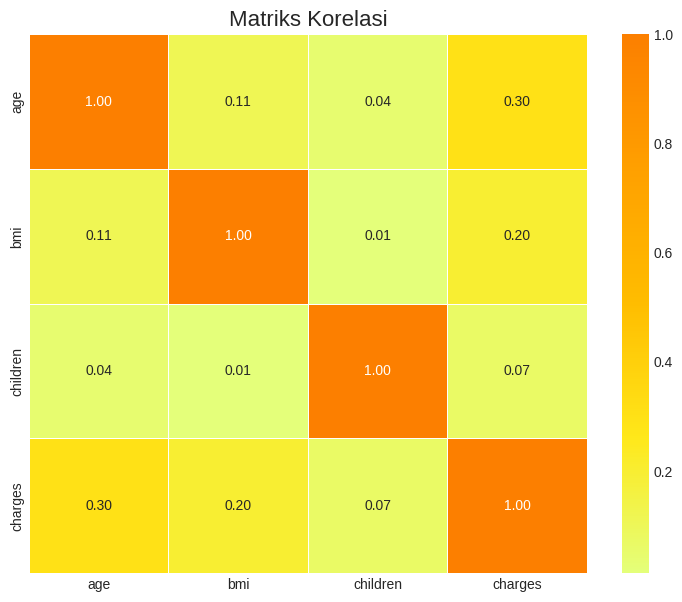

In [ ]:
#Matriks korelasi
numerical_cols = ['age', 'bmi', 'children', 'charges']
plt.figure(figsize=(9, 7))

# Hitung dan Plot Matriks Korelasi
sns.heatmap(
    df[numerical_cols].corr(),
    annot=True,              # Tampilkan nilai korelasi pada heatmap
    cmap='Wistia',         # Pilihan skema warna
    fmt=".2f",               # Format angka hingga 2 desimal
    linewidths=0.5         # Garis antar sel
)

plt.title('Matriks Korelasi', fontsize=16)
plt.show()

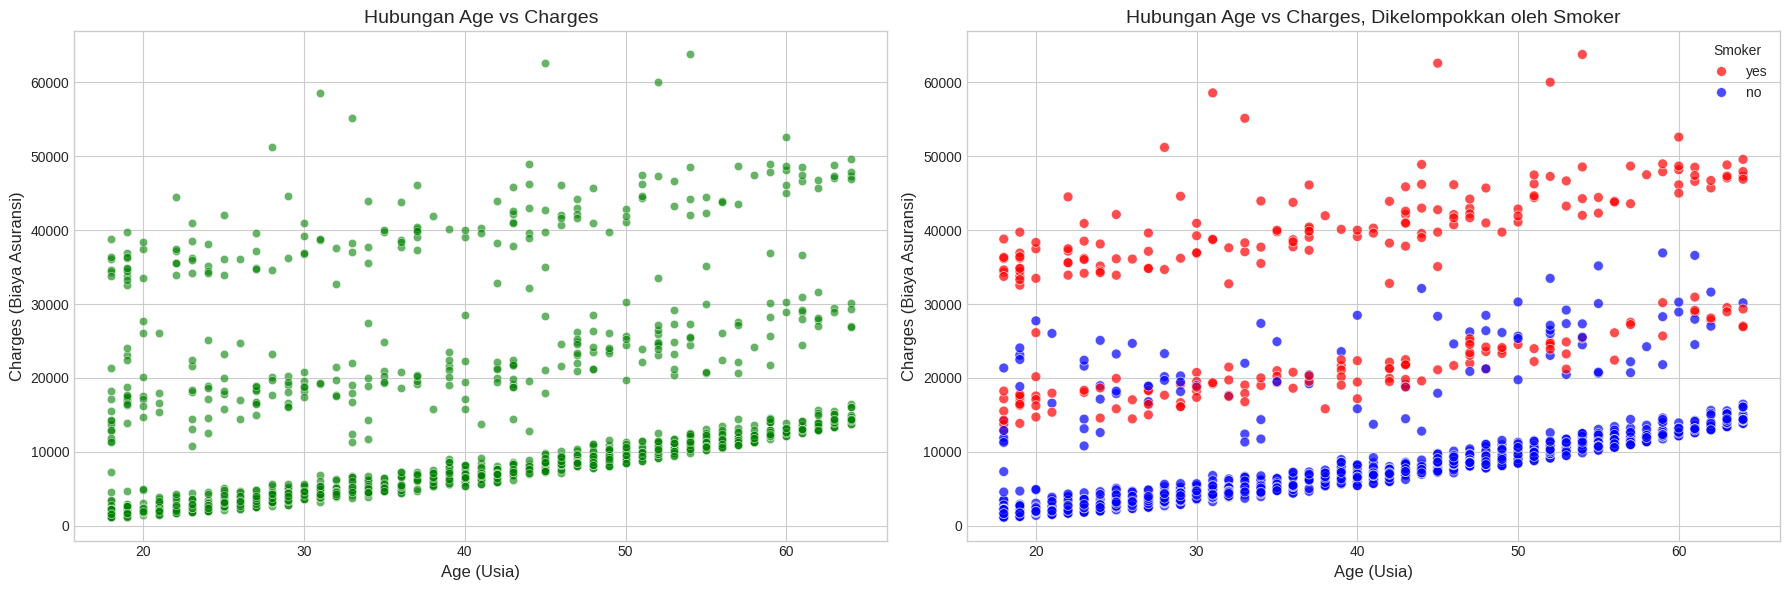

In [ ]:
# Membuat 2 plot dalam 1 baris
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
plt.style.use('seaborn-v0_8-whitegrid') # Atur style

# --- PLOT 1: Scatter Plot (age vs charges) ---
sns.scatterplot(
    x='age',
    y='charges',
    data=df,
    ax=axes[0],          # Plot di subplot pertama (index 0)
    color='green',
    alpha=0.6            # Transparansi
)
axes[0].set_title('Hubungan Age vs Charges', fontsize=14)
axes[0].set_xlabel('Age (Usia)', fontsize=12)
axes[0].set_ylabel('Charges (Biaya Asuransi)', fontsize=12)


# --- PLOT 2: Scatter Plot dengan Pembedaan Warna Smoker (Interaksi Fitur) ---
sns.scatterplot(
    x='age',
    y='charges',
    hue='smoker',        # Pembedaan warna berdasarkan status 'smoker'
    data=df,
    ax=axes[1],          # Plot di subplot kedua (index 1)
    palette={'yes': 'red', 'no': 'blue'}, # Kustomisasi warna
    s=50,                # Ukuran titik
    alpha=0.7
)
axes[1].set_title('Hubungan Age vs Charges, Dikelompokkan oleh Smoker', fontsize=14)
axes[1].set_xlabel('Age (Usia)', fontsize=12)
axes[1].set_ylabel('Charges (Biaya Asuransi)', fontsize=12)
axes[1].legend(title='Smoker')

plt.tight_layout() # Sesuaikan jarak antar subplot
plt.show()

# Preprocessing data

In [ ]:
#Menghapus baris yang terduplikat
df.drop_duplicates(inplace=True)
df.shape

(1337, 7)

In [ ]:
#Transformasi Logaritma pada Variabel Target
# Buat kolom baru dengan nilai charges yang sudah di-transformasi
df['charges_log'] = np.log1p(df['charges'])

#INI YA NIS
# Saat melatih model, gunakan 'charges_log' sebagai variabel target (y).
# Ingat: Setelah prediksi, Anda harus melakukan eksponensiasi balik (antilog)
# menggunakan np.expm1() untuk mendapatkan biaya yang sebenarnya.

In [ ]:
#One hot encoding pada variabel region
df_encoded = pd.get_dummies(df, columns=['region'], prefix='region', dtype=int)
df_encoded.sample(5)

,age,sex,bmi,children,smoker,charges,charges_log,region_northeast,region_northwest,region_southeast,region_southwest
1236,63,female,21.66,0,no,14449.8544,9.578509,1,0,0,0
106,19,female,28.40,1,no,2331.5190,7.754704,0,0,0,1
403,49,male,32.30,3,no,10269.4600,9.237027,0,1,0,0
418,64,male,39.16,1,no,14418.2804,9.576322,0,0,1,0
650,49,female,42.68,2,no,9800.8882,9.190330,0,0,1,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
#Label encoding untuk 'smoker'
label_encoder = LabelEncoder()
df_encoded['smoker_encoded'] = label_encoder.fit_transform(df_encoded['smoker'])
df_encoded.sample(5)

,age,sex,bmi,children,smoker,charges,charges_log,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded
1202,22,male,32.110,0,no,2055.32490,7.628676,0,1,0,0,0
26,63,female,23.085,0,no,14451.83515,9.578646,1,0,0,0,0
1048,25,female,22.515,1,no,3594.17085,8.187347,0,1,0,0,0
1032,30,female,27.930,0,no,4137.52270,8.328094,1,0,0,0,0
524,42,male,26.070,1,yes,38245.59327,10.551810,0,0,1,0,1


In [ ]:
#Label encoding untuk "sex"
df_encoded['sex_encoded'] = label_encoder.fit_transform(df_encoded['sex'])
df_encoded.sample(5)

,age,sex,bmi,children,smoker,charges,charges_log,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded,sex_encoded
1158,20,female,30.590,0,no,2459.72010,7.808209,1,0,0,0,0,0
1331,23,female,33.400,0,no,10795.93733,9.287018,0,0,0,1,0,0
849,55,male,32.775,0,no,10601.63225,9.268858,0,1,0,0,0,1
501,43,male,26.030,0,no,6837.36870,8.830304,1,0,0,0,0,1
669,40,female,29.810,1,no,6500.23590,8.779748,0,0,1,0,0,0


In [ ]:
df_encoded = df_encoded[[x for x in df_encoded.columns if x not in ['smoker', 'sex']]]
df_encoded.sample(5)

,age,bmi,children,charges,charges_log,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded,sex_encoded
457,57,30.495,0,11840.77505,9.379389,0,1,0,0,0,0
1189,23,28.000,0,13126.67745,9.482478,0,0,0,1,0,0
1288,20,39.400,2,38344.56600,10.554394,0,0,0,1,1,1
887,36,30.020,0,5272.17580,8.570388,0,1,0,0,0,0
1030,46,23.655,1,21677.28345,9.984066,0,1,0,0,1,0


In [ ]:
#membagi kelas target dan fitur (X)
# Kolom yang tidak boleh menjadi fitur (X)
kolom_buang = ['charges', 'charges_log']

X = df_encoded.drop(columns=kolom_buang, errors='ignore')
y = df_encoded['charges_log']

In [ ]:
X.head()

,age,bmi,children,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded,sex_encoded
0,19,27.900,0,0,0,0,1,1,0
1,18,33.770,1,0,0,1,0,0,1
2,28,33.000,3,0,0,1,0,0,1
3,33,22.705,0,0,1,0,0,0,1
4,32,28.880,0,0,1,0,0,0,1


In [ ]:
y.head()

,charges_log
0,9.734236
1,7.453882
2,8.400763
3,9.998137
4,8.260455


In [ ]:
#split data into train and split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print("\n Hasil Pembagian Data (80:20):")
print(f"X_train (Data Latih Fitur): {X_train.shape}")
print(f"X_test (Data Uji Fitur): {X_test.shape}")
print(f"y_train (Data Latih Target): {y_train.shape}")
print(f"y_test (Data Uji Target): {y_test.shape}")


 Hasil Pembagian Data (80:20):
X_train (Data Latih Fitur): (1069, 9)
X_test (Data Uji Fitur): (268, 9)
y_train (Data Latih Target): (1069,)
y_test (Data Uji Target): (268,)


In [ ]:
X_train.dtypes

,0
age,int64
bmi,float64
children,int64
region_northeast,int64
region_northwest,int64
region_southeast,int64
region_southwest,int64
smoker_encoded,int64
sex_encoded,int64


In [ ]:
y_train.head()

,charges_log
1114,7.782013
968,8.095863
599,10.418494
170,9.503487
275,9.181616


In [ ]:
y_test.head()

,charges_log
900,9.069912
1064,8.649951
1256,9.344674
298,10.564818
237,8.403846


In [ ]:
X_train.head()

,age,bmi,children,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded,sex_encoded
1114,23,24.510,0,1,0,0,0,0,1
968,21,25.745,2,1,0,0,0,0,1
599,52,37.525,2,0,1,0,0,0,0
170,63,41.470,0,0,0,1,0,0,1
275,47,26.600,2,1,0,0,0,0,0


In [ ]:
X_test.head()

,age,bmi,children,region_northeast,region_northwest,region_southeast,region_southwest,smoker_encoded,sex_encoded
900,49,22.515,0,1,0,0,0,0,1
1064,29,25.600,4,0,0,0,1,0,0
1256,51,36.385,3,0,1,0,0,0,0
298,31,34.390,3,0,1,0,0,1,1
237,31,38.390,2,0,0,1,0,0,1


# **Regression tree prediction**

### baseline

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
#model
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

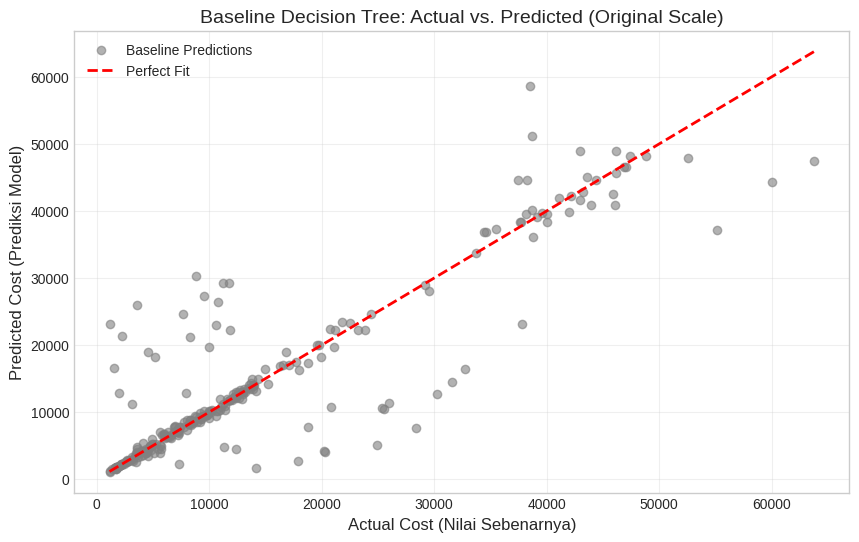

In [ ]:
#plot
# 1. Siapkan Data Skala Asli (Inverse Transform)
y_pred_baseline_original = np.expm1(dt_predictions)
y_test_original = np.expm1(y_test)

plt.figure(figsize=(10, 6))

# 2. Scatter Plot Baseline
plt.scatter(y_test_original, y_pred_baseline_original, color='gray', alpha=0.6, label='Baseline Predictions')

# 3. Garis Diagonal (Perfect Fit)
#
min_val = min(y_test_original)
max_val = max(y_test_original)
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

# plot
plt.title('Baseline Decision Tree: Actual vs. Predicted (Original Scale)', fontsize=14)
plt.xlabel('Actual Cost (Nilai Sebenarnya)', fontsize=12)
plt.ylabel('Predicted Cost (Prediksi Model)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [ ]:
#evaluasi

# 2. Kembalikan ke skala asli (Inverse Transform)
# Gunakan np.expm1 jika saat training pakai np.log1p
y_pred_original = np.expm1(dt_predictions)
y_test_original = np.expm1(y_test)

# 3. Hitung Metrik pada Skala Asli
mse_final = mean_squared_error(y_test_original, y_pred_original)
rmse_final = np.sqrt(mse_final)
mae_final = mean_absolute_error(y_test_original, y_pred_original)
r2_final = r2_score(y_test_original, y_pred_original)

# Hitung MAPE Manual (agar aman)
mape_final = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original)) * 100

print('== evaluasi baseline ==')
print(f"Original Scale MSE: {mse_final:.4f}")
print(f"Original Scale RMSE: {rmse_final:.4f}")
print(f"Original Scale MAE: {mae_final:.4f}")
print(f"Original Scale MAPE: {mape_final:.2f}%")
print(f"Original Scale R2: {r2_final:.4f}")

== evaluasi baseline ==
Original Scale MSE: 37930409.1616
Original Scale RMSE: 6158.7669
Original Scale MAE: 2835.1316
Original Scale MAPE: 37.10%
Original Scale R2: 0.7936


cek overfitting

In [ ]:
train_score = dt_model.score(X_train, y_train)
test_score = dt_model.score(X_test, y_test)

print(f"Training R2: {train_score}")
print(f"Testing R2: {test_score:.4f}")

if train_score - test_score > 0.1:
    print("Status: Overfitting-> Lanjut ke Tuning")
else:
    print("Status: Fit atau Underfitting")

Training R2: 1.0
Testing R2: 0.7180
Status: Overfitting-> Lanjut ke Tuning


### w/ tuning hyperparameter

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Feature Engineering (Sangat Recommended untuk dataset ini)
# Pastikan dilakukan pada copy agar tidak merusak data asli jika run ulang
X_train_eng = X_train.copy()
X_test_eng = X_test.copy()

X_train_eng['bmi_smoker'] = X_train_eng['bmi'] * X_train_eng['smoker_encoded']
X_test_eng['bmi_smoker'] = X_test_eng['bmi'] * X_test_eng['smoker_encoded']

# 2. Setup GridSearch
param_grid = {
    'max_depth': [4, 6, 8, 9, 10],
    'min_samples_leaf': [10, 20, 30],  # Mencegah overfitting pada nilai BMI spesifik
    'min_samples_split': [20, 40, 60]
}

# Ingat: y_train diasumsikan sudah di-Log (np.log1p)
dt = DecisionTreeRegressor(random_state=42)
grid = GridSearchCV(dt, param_grid, cv=5, scoring='neg_mean_squared_error')

# 3. Training
grid.fit(X_train_eng, y_train) # y_train log scale

print("Best Params:", grid.best_params_)

# 4. Prediksi & Evaluasi (Inverse Transform)
best_model = grid.best_estimator_
pred_log = best_model.predict(X_test_eng)

# Kembalikan ke skala asli (Rupiah/Dollar)
y_pred_final = np.expm1(pred_log)
y_test_final = np.expm1(y_test)

# Hitung Metrik
mse = mean_squared_error(y_test_final, y_pred_final)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_final, y_pred_final)
mape = np.mean(np.abs((y_test_final - y_pred_final) / y_test_final)) * 100
r2 = r2_score(y_test_final, y_pred_final)

#evaluasi tuning
print('== evaluasi tuning ==')
print(f"Final R2 Score: {r2:.4f}")
print(f"Final MSE: {mse:.4f}")
print(f"Final RMSE: {rmse:.2f}")
print(f"Final MAE: {mae:.2f}")
print(f"Final MAPE: {mape:.2f}%")

Best Params: {'max_depth': 4, 'min_samples_leaf': 10, 'min_samples_split': 20}
== evaluasi tuning ==
Final R2 Score: 0.8957
Final MSE: 19168285.2303
Final RMSE: 4378.16
Final MAE: 2287.93
Final MAPE: 20.60%


In [ ]:
# Buat DataFrame perbandingan
comp = pd.DataFrame({
    'Model': ['Baseline model','Decision Tree (Tuned)'],
    'R2 Score': [0.7840, f'{r2:.4f}'],
    'MSE' : [39690042.6483, f'{mse:.4f}'],
    'RMSE': [6300.0034,f'{rmse:.4f}'],
    'MAPE': [f"39.27%", f"{mape:.2f}%"],
    'MAE': [3009.9635, f'{mae:.2f}']
} )

print("=== LEADERBOARD MODEL ===")
print(comp)

=== LEADERBOARD MODEL ===
                   Model R2 Score            MSE       RMSE    MAPE        MAE
0         Baseline model    0.784  39690042.6483  6300.0034  39.27%  3009.9635
1  Decision Tree (Tuned)   0.8957  19168285.2303  4378.1600  20.60%    2287.93


In [ ]:
#overfitting
train_score = best_model.score(X_train_eng, y_train)
test_score = best_model.score(X_test_eng, y_test)

print(f"Training R2: {train_score:.4f}")
print(f"Testing R2: {test_score:.4f}")

if train_score - test_score > 0.1:
    print("Status: Overfitting-> Lanjut ke Tuning")
else:
    print("Status: Fit atau Underfitting")

Training R2: 0.8184
Testing R2: 0.8602
Status: Fit atau Underfitting


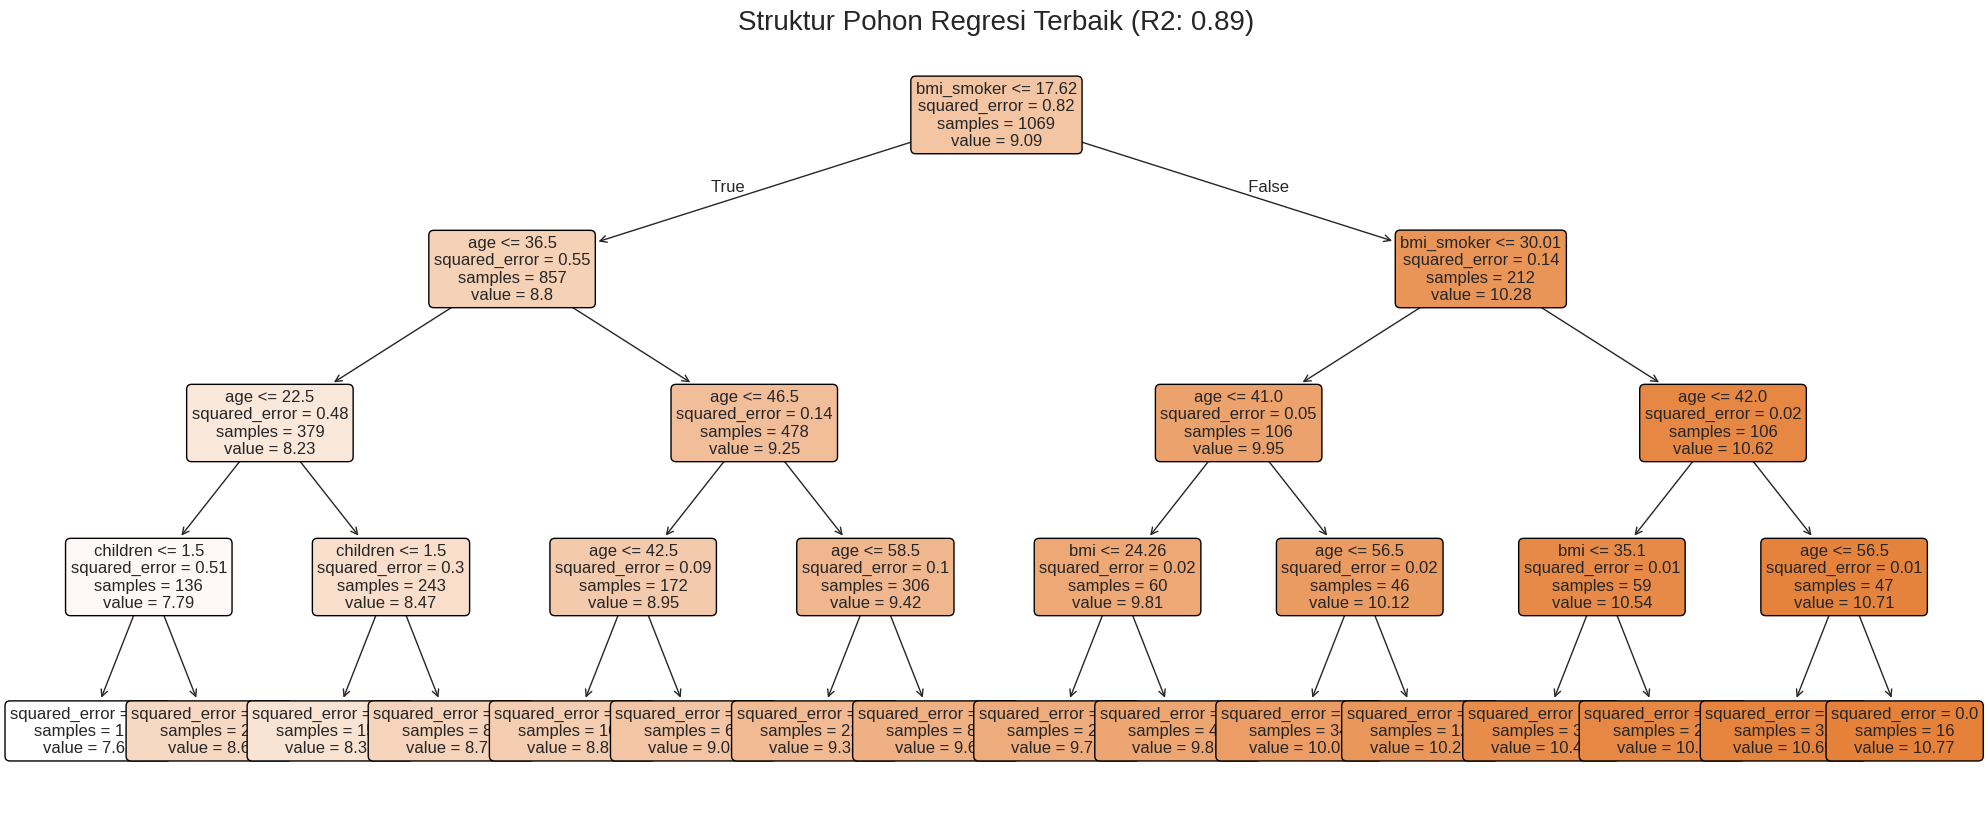

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 10))
plot_tree(best_model,
          feature_names=X_train_eng.columns,
          filled=True,
          fontsize=12,
          rounded=True,
          precision=2)
plt.title("Struktur Pohon Regresi Terbaik (R2: 0.89)", fontsize=20)
plt.show()

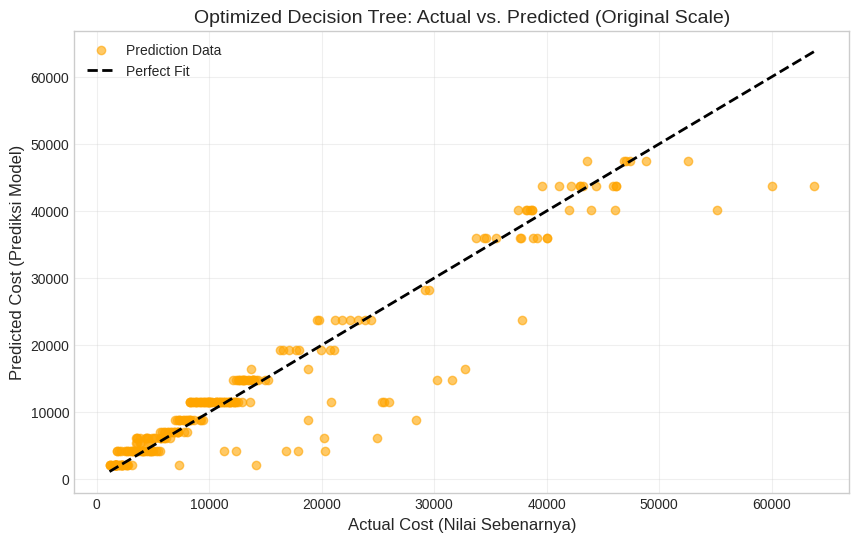

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 1. Scatter Plot (Titik-titik data)
# Gunakan y_test_final dan y_pred_final dari hasil tuning terakhir
plt.scatter(y_test_final, y_pred_final, color='orange', alpha=0.6, label='Prediction Data')

# 2. Garis Diagonal (Garis Sempurna)
min_val = min(y_test_final)
max_val = max(y_test_final)
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Fit')

# 3. Plot
plt.title('Optimized Decision Tree: Actual vs. Predicted (Original Scale)', fontsize=14)
plt.xlabel('Actual Cost (Nilai Sebenarnya)', fontsize=12)
plt.ylabel('Predicted Cost (Prediksi Model)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

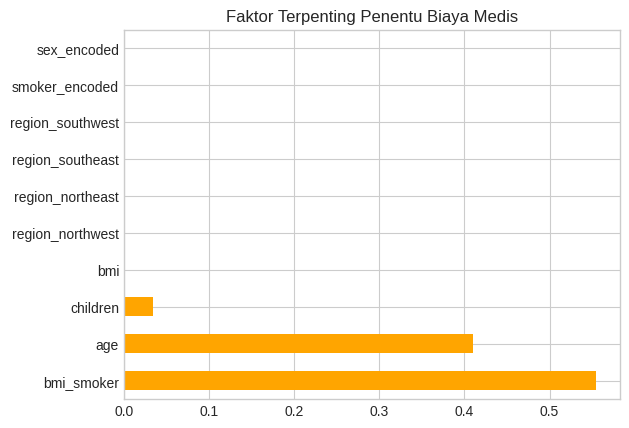

In [ ]:
# Ambil importance dari model terbaik
feat_importances = pd.Series(best_model.feature_importances_, index=X_train_eng.columns)

# Plot 10 fitur terpenting
feat_importances.nlargest(10).plot(kind='barh', color='orange')
plt.title("Faktor Terpenting Penentu Biaya Medis")
plt.show()

In [ ]:
df_importance = feat_importances.reset_index()

df_importance.columns = ['Nama Fitur', 'Nilai Importance']

df_importance = df_importance.sort_values(by='Nilai Importance', ascending=False).reset_index(drop=True)

print("=== TABEL FEATURE IMPORTANCE ===")
print(df_importance.round(4))

=== TABEL FEATURE IMPORTANCE ===
         Nama Fitur  Nilai Importance
0        bmi_smoker            0.5550
1               age            0.4104
2          children            0.0339
3               bmi            0.0007
4  region_northwest            0.0000
5  region_northeast            0.0000
6  region_southeast            0.0000
7  region_southwest            0.0000
8    smoker_encoded            0.0000
9       sex_encoded            0.0000


# Random forest (for comparison)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Inisialisasi model Random Forest Regressor
# Gunakan parameter yang umumnya baik sebagai starting point atau hasil dari tuning sebelumnya jika ada
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 untuk menggunakan semua core CPU

# Latih model pada data latih
rf_model.fit(X_train_eng, y_train)

# Lakukan prediksi pada data uji (dalam skala log)
rf_predictions_log = rf_model.predict(X_test_eng)

== Evaluasi Random Forest ==
Original Scale MSE: 19288881.3472
Original Scale RMSE: 4391.9109
Original Scale MAE: 2059.6358
Original Scale MAPE: 19.84%
Original Scale R2: 0.8950


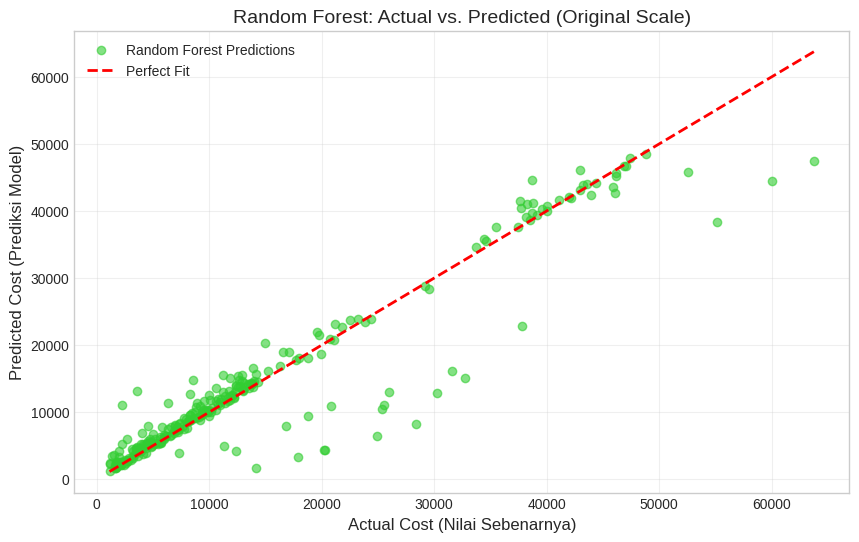

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Kembalikan prediksi dan nilai sebenarnya ke skala asli
rf_predictions_original = np.expm1(rf_predictions_log)
y_test_original_rf = np.expm1(y_test)

# Hitung Metrik Evaluasi
mse_rf = mean_squared_error(y_test_original_rf, rf_predictions_original)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test_original_rf, rf_predictions_original)
mape_rf = np.mean(np.abs((y_test_original_rf - rf_predictions_original) / y_test_original_rf)) * 100
r2_rf = r2_score(y_test_original_rf, rf_predictions_original)

print('== Evaluasi Random Forest ==')
print(f"Original Scale MSE: {mse_rf:.4f}")
print(f"Original Scale RMSE: {rmse_rf:.4f}")
print(f"Original Scale MAE: {mae_rf:.4f}")
print(f"Original Scale MAPE: {mape_rf:.2f}%")
print(f"Original Scale R2: {r2_rf:.4f}")

# Plot Actual vs. Predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original_rf, rf_predictions_original, color='limegreen', alpha=0.6, label='Random Forest Predictions')

# Garis diagonal untuk 'perfect fit'
min_val_rf = min(y_test_original_rf.min(), rf_predictions_original.min())
max_val_rf = max(y_test_original_rf.max(), rf_predictions_original.max())
plt.plot([min_val_rf, max_val_rf], [min_val_rf, max_val_rf], color='red', linestyle='--', linewidth=2, label='Perfect Fit')

plt.title('Random Forest: Actual vs. Predicted (Original Scale)', fontsize=14)
plt.xlabel('Actual Cost (Nilai Sebenarnya)', fontsize=12)
plt.ylabel('Predicted Cost (Prediksi Model)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# Cek overfitting untuk Random Forest (pada skala log)
train_r2_rf = rf_model.score(X_train_eng, y_train)
test_r2_rf = rf_model.score(X_test_eng, y_test)

print(f"Training R2 (log scale): {train_r2_rf:.4f}")
print(f"Testing R2 (log scale): {test_r2_rf:.4f}")

if train_r2_rf - test_r2_rf > 0.1:
    print("Status: Random Forest mungkin mengalami Overfitting.")
else:
    print("Status: Random Forest terlihat Fit atau Underfitting.")


Training R2 (log scale): 0.9704
Testing R2 (log scale): 0.8502
Status: Random Forest mungkin mengalami Overfitting.


In [ ]:
# Buat DataFrame perbandingan
comparison = pd.DataFrame({
    'Model': ['Decision Tree (Tuned)', 'Random Forest (Default)'],
    'R2 Score': [0.8957, r2_rf],
    'MSE' : [19168285.2303, mse_rf],
    'RMSE': [4378.16, rmse_rf],
    'MAPE': [f"20.60%", f"{mape_rf:.2f}%"],
    'MAE': [2287.93, mae_rf]
})

print("=== LEADERBOARD MODEL ===")
print(comparison)

=== LEADERBOARD MODEL ===
                     Model  R2 Score           MSE         RMSE    MAPE  \
0    Decision Tree (Tuned)   0.89570  1.916829e+07  4378.160000  20.60%   
1  Random Forest (Default)   0.89503  1.928888e+07  4391.910899  19.84%   

           MAE  
0  2287.930000  
1  2059.635831  


# Hasil
Berdasarkan hasil evaluasi, model Random Forest memberikan performa terbaik dengan nilai MAPE paling rendah dibandingkan dua pendekatan lainnya. Hal ini menunjukkan bahwa metode ensemble mampu meningkatkan akurasi prediksi dengan mengurangi overfitting yang sering terjadi pada single decision tree.